In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#J’ai identifié un problème de parsing du dataset lié au séparateur et corrigé l’import pour structurer correctement les données.
# De base j'avais mis avec un point-virgule, mais le dataset utilise une virgule comme séparateur. 
# J'ai donc modifié le code pour utiliser sep="," lors de la lecture du fichier CSV.   
df = pd.read_csv("data/energy_data.csv", sep=",")
df.head()

,index,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0,1/1/07,0:00:00,2.58,0.136,241.97,10.6,0,0,0.0
1,1,1/1/07,0:01:00,2.552,0.1,241.75,10.4,0,0,0.0
2,2,1/1/07,0:02:00,2.55,0.1,241.64,10.4,0,0,0.0
3,3,1/1/07,0:03:00,2.55,0.1,241.71,10.4,0,0,0.0
4,4,1/1/07,0:04:00,2.554,0.1,241.98,10.4,0,0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  260640 non-null  int64  
 1   Date                   260640 non-null  str    
 2   Time                   260640 non-null  str    
 3   Global_active_power    260640 non-null  str    
 4   Global_reactive_power  260640 non-null  str    
 5   Voltage                260640 non-null  str    
 6   Global_intensity       260640 non-null  str    
 7   Sub_metering_1         260640 non-null  str    
 8   Sub_metering_2         260640 non-null  str    
 9   Sub_metering_3         256869 non-null  float64
dtypes: float64(1), int64(1), str(8)
memory usage: 19.9 MB


In [9]:
# Drop index car inutile et peut causer des problèmes de manipulation
df.drop(columns=['index'], inplace=True, errors='ignore')

# Convert numeric columns
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [26]:
#Pour verifier qu'on a bien convertie les str en valeur numerique et identifier les valeurs manquantes
df.info()
#Pour detecter les valeurs manquantes
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Date                   260640 non-null  str           
 1   Time                   260640 non-null  str           
 2   Global_active_power    256869 non-null  float64       
 3   Global_reactive_power  256869 non-null  float64       
 4   Voltage                256869 non-null  float64       
 5   Global_intensity       256869 non-null  float64       
 6   Sub_metering_1         256869 non-null  float64       
 7   Sub_metering_2         256869 non-null  float64       
 8   Sub_metering_3         256869 non-null  float64       
 9   DateTime               260640 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(7), str(2)
memory usage: 19.9 MB


Date                        0
Time                        0
Global_active_power      3771
Global_reactive_power    3771
Voltage                  3771
Global_intensity         3771
Sub_metering_1           3771
Sub_metering_2           3771
Sub_metering_3           3771
DateTime                    0
dtype: int64

In [ ]:
df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
#Créer de nouvelles fonctionnalités temporelles à partir de la colonne "DateTime" 

C:\Users\hp\AppData\Local\Temp\ipykernel_20340\1610594515.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"])


In [ ]:
df.info()
print(df['DateTime'])
print(df['DateTime'].isnull().sum())
#on verifie le nombre de valeurs manquantes dans la colonne DateTime pour s'assurer que la conversion s'est bien passée.

<class 'pandas.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Date                   260640 non-null  str           
 1   Time                   260640 non-null  str           
 2   Global_active_power    256869 non-null  float64       
 3   Global_reactive_power  256869 non-null  float64       
 4   Voltage                256869 non-null  float64       
 5   Global_intensity       256869 non-null  float64       
 6   Sub_metering_1         256869 non-null  float64       
 7   Sub_metering_2         256869 non-null  float64       
 8   Sub_metering_3         256869 non-null  float64       
 9   DateTime               260640 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(7), str(2)
memory usage: 19.9 MB
0        2007-01-01 00:00:00
1        2007-01-01 00:01:00
2        2007-01-01 00:02:00
3        2007-01-01 00:03

In [ ]:
#Créer de nouvelles fonctionnalités temporelles à partir de la colonne "DateTime" pour capturer les tendances saisonnières et horaires dans la consommation d'énergie.
df["hour"] = df["DateTime"].dt.hour
df["day_name"] = df["DateTime"].dt.day_name()
df["month"] = df["DateTime"].dt.month
df["is_weekend"] = df["DateTime"].dt.dayofweek >= 5

In [29]:
df[["DateTime", "hour", "day_name", "month", "is_weekend"]].head()

,DateTime,hour,day_name,month,is_weekend
0,2007-01-01 00:00:00,0,Monday,1,False
1,2007-01-01 00:01:00,0,Monday,1,False
2,2007-01-01 00:02:00,0,Monday,1,False
3,2007-01-01 00:03:00,0,Monday,1,False
4,2007-01-01 00:04:00,0,Monday,1,False


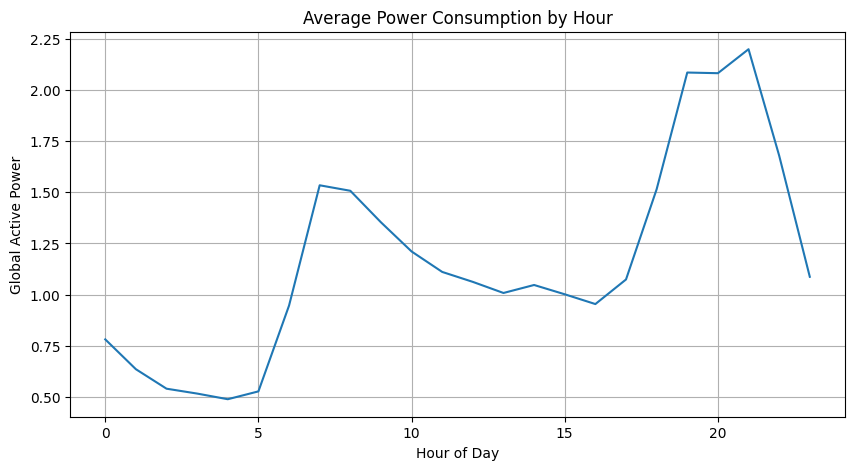

In [30]:
#on analyse la consommation d'énergie en fonction de l'heure de la journée pour identifier les pics de consommation et les périodes creuses via une visualisation graphique.
import matplotlib.pyplot as plt
hourly_avg = df.groupby("hour")["Global_active_power"].mean()
plt.figure(figsize=(10,5))
hourly_avg.plot()
plt.title("Average Power Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Global Active Power")
plt.grid(True)
plt.show()

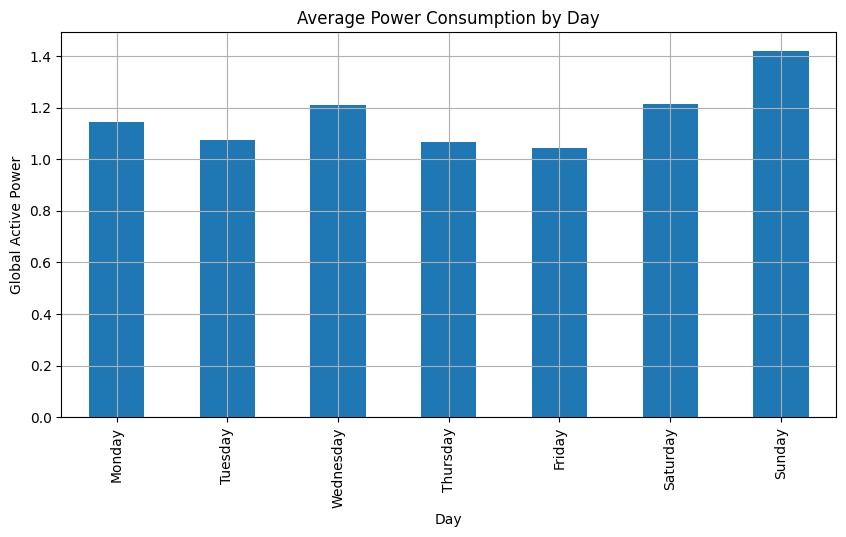

In [31]:
#on analyse la consommation d'énergie en fonction du jour de la semaine pour identifier les tendances hebdomadaires et les différences entre les jours de semaine et les week-ends via une visualisation graphique.
daily_avg = df.groupby("day_name")["Global_active_power"].mean()

daily_avg = daily_avg.reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

plt.figure(figsize=(10,5))
daily_avg.plot(kind="bar")
plt.title("Average Power Consumption by Day")
plt.xlabel("Day")
plt.ylabel("Global Active Power")
plt.grid(True)
plt.show()

In [32]:
#detection d'anomalies dans la consommation d'énergie en utilisant une méthode simple basée sur l'écart type pour identifier les points de données qui s'écartent significativement de la moyenne.
mean_power = df["Global_active_power"].mean()
std_power = df["Global_active_power"].std()

df["anomaly"] = abs(df["Global_active_power"] - mean_power) > 2 * std_power

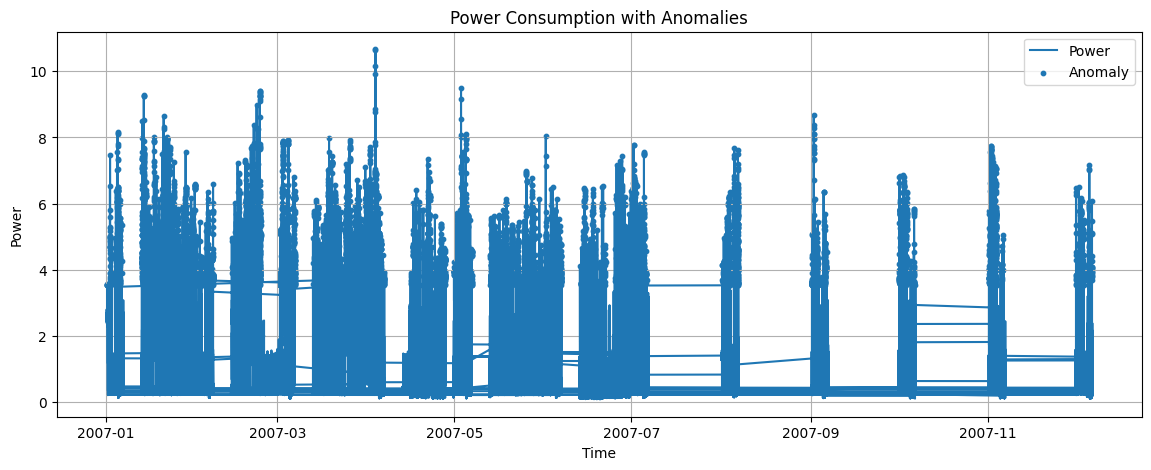

In [35]:
#visualisation des anomalies détectées dans la consommation d'énergie pour identifier les points de données qui s'écartent significativement de la moyenne.
plt.figure(figsize=(14,5))
plt.plot(df["DateTime"], df["Global_active_power"], label="Power")

plt.scatter(
    df.loc[df["anomaly"], "DateTime"],
    df.loc[df["anomaly"], "Global_active_power"],
    s=10,
    label="Anomaly"
)

plt.title("Power Consumption with Anomalies")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.show()

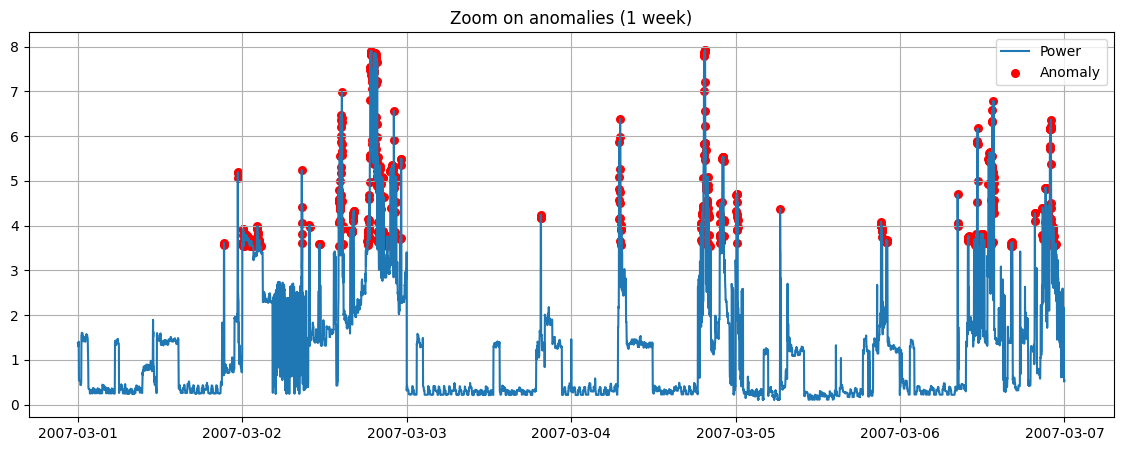

In [36]:
#le graphique est beaucoup trop dense pour visualiser les anomalies clairement, surtout si le dataset est volumineux.
#Une approche plus efficace serait de visualiser les anomalies sur une période plus courte (par exemple une semaine ou un mois) ou d'utiliser des techniques de visualisation plus adaptées pour les séries temporelles, comme les boxplots.
#la je vais visualiser les anomalies sur une semaine pour mieux les identifier
df_sample = df[(df["DateTime"] >= "2007-03-01") & (df["DateTime"] <= "2007-03-07")]

plt.figure(figsize=(14,5))
plt.plot(df_sample["DateTime"], df_sample["Global_active_power"], label="Power")

plt.scatter(
    df_sample.loc[df_sample["anomaly"], "DateTime"],
    df_sample.loc[df_sample["anomaly"], "Global_active_power"],
    color="red",
    s=30,
    label="Anomaly"
)

plt.legend()
plt.title("Zoom on anomalies (1 week)")
plt.grid(True)
plt.show()

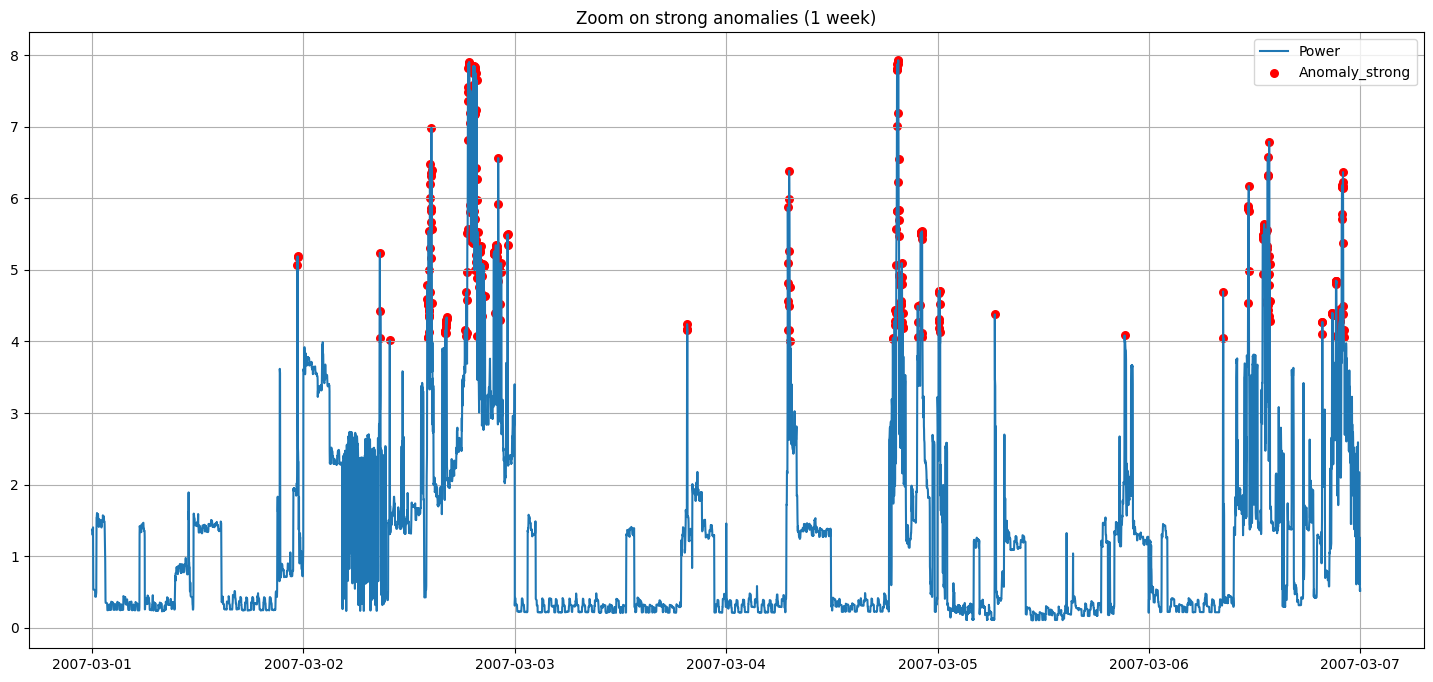

In [40]:
#La détection d’anomalies met en évidence des pics de consommation inhabituels. Cependant, certains de ces pics peuvent correspondre à des comportements normaux liés à des usages énergétiques ponctuels. Ce qu'on peut faire c'est filtrer les anomalies faibles
df["anomaly_strong"] = df["anomaly"] & (df["Global_active_power"] > 4)
df_sample = df[(df["DateTime"] >= "2007-03-01") & (df["DateTime"] <= "2007-03-07")]
plt.figure(figsize=(18,8))
plt.plot(df_sample["DateTime"], df_sample["Global_active_power"], label="Power")

plt.scatter(
    df_sample.loc[df_sample["anomaly_strong"], "DateTime"],
    df_sample.loc[df_sample["anomaly_strong"], "Global_active_power"],
    color="red",
    s=30,
    label="Anomaly_strong"
)

plt.legend()
plt.title("Zoom on strong anomalies (1 week)")
plt.grid(True)
plt.show()

In [ ]:
#La visualisation met en évidence plusieurs anomalies fortes correspondant à des pics de consommation électrique.

#Ces anomalies sont principalement concentrées durant les périodes de forte activité, ce qui suggère qu’elles peuvent être liées à des usages énergétiques spécifiques plutôt qu’à du bruit aléatoire.

#Cependant, certaines anomalies détectées peuvent correspondre à des comportements normaux pendant les heures de pointe, ce qui met en évidence les limites d’une méthode de détection basée sur un seuil global.

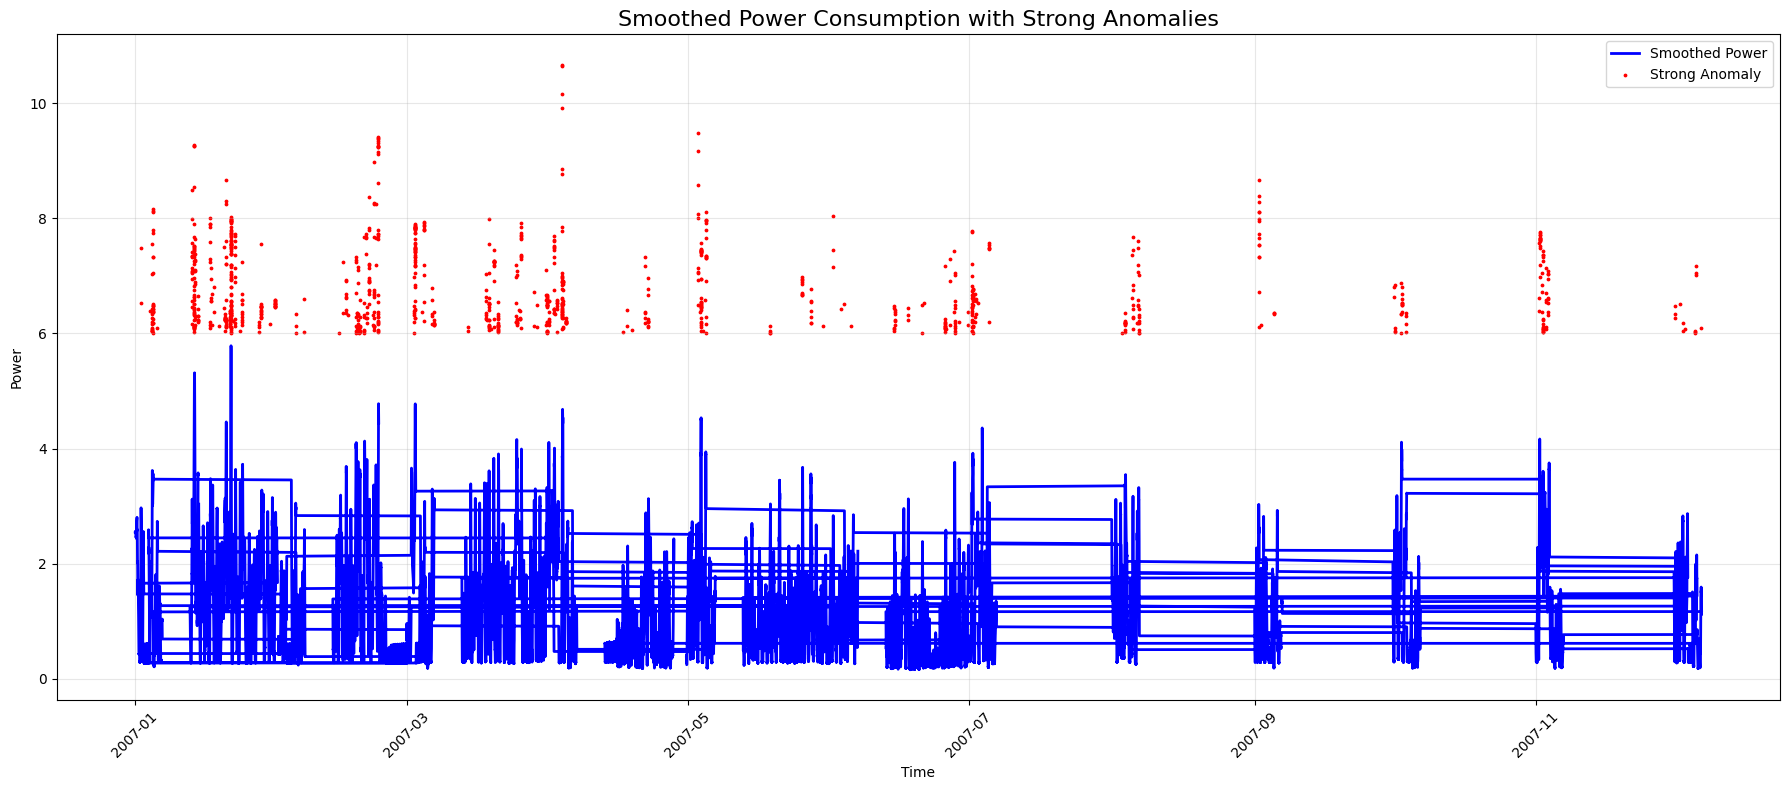

In [44]:
#Pour améliorer la détection d’anomalies, on peut appliquer un lissage sur la série temporelle pour mieux identifier les tendances et les écarts significatifs. Par exemple, en utilisant une moyenne mobile pour lisser les données avant de détecter les anomalies.
df["anomaly_strong"] = df["anomaly"] & (df["Global_active_power"] > 6)
#J'ai augmenté le seuil pour ne garder que les anomalies les plus fortes, ce qui permet de mieux visualiser les pics de consommation significatifs.
df["rolling_mean"] = df["Global_active_power"].rolling(window=180).mean()

plt.figure(figsize=(18,8))

plt.plot(
    df["DateTime"],
    df["rolling_mean"],
    label="Smoothed Power",
    linewidth=2,
    color="blue"
)

plt.scatter(
    df.loc[df["anomaly_strong"], "DateTime"],
    df.loc[df["anomaly_strong"], "Global_active_power"],
    color="red",
    s=3,
    label="Strong Anomaly"
)

plt.legend()
plt.title("Smoothed Power Consumption with Strong Anomalies", fontsize=16)
plt.xlabel("Time")
plt.ylabel("Power")
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [34]:
### limites de la méthode
#Cette approche basée sur la moyenne globale et l’écart-type permet une première détection rapide des anomalies.

#Cependant, elle présente des limites importantes :
#- elle ne prend pas en compte la dimension temporelle des données,
#- elle suppose que le comportement de consommation est constant dans le temps,
#- elle peut considérer comme anormales des valeurs pourtant normales à certaines heures (ex : pic en soirée).

#Une approche plus robuste consiste à analyser les anomalies en fonction du contexte temporel (par exemple par heure ou par jour).

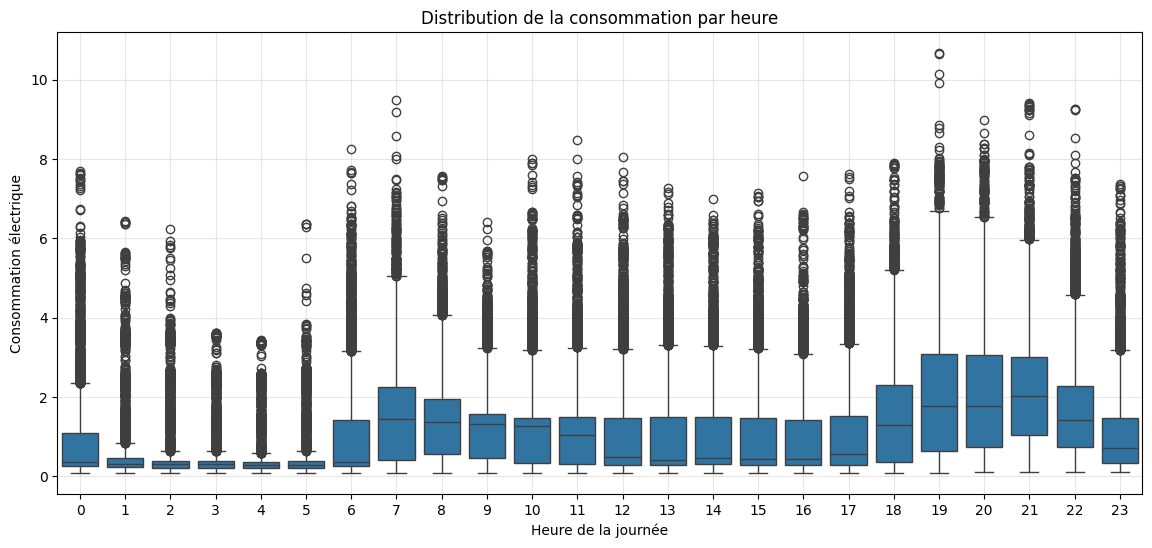

In [56]:
#On va donc analyser les anomalies en fonction de l'heure pour mieux identifier les pics de consommation spécifiques à certaines périodes de la journée.
#J’ai utilisé un boxplot par heure pour analyser la distribution de la consommation électrique et identifier les variations et anomalies selon les moments de la journée.” 
import seaborn as sns


plt.figure(figsize=(14,6))

sns.boxplot(
    x="hour",
    y="Global_active_power",
    data=df
)

plt.title("Distribution de la consommation par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Consommation électrique")
plt.grid(True, alpha=0.3)

plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_20340\1437472942.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


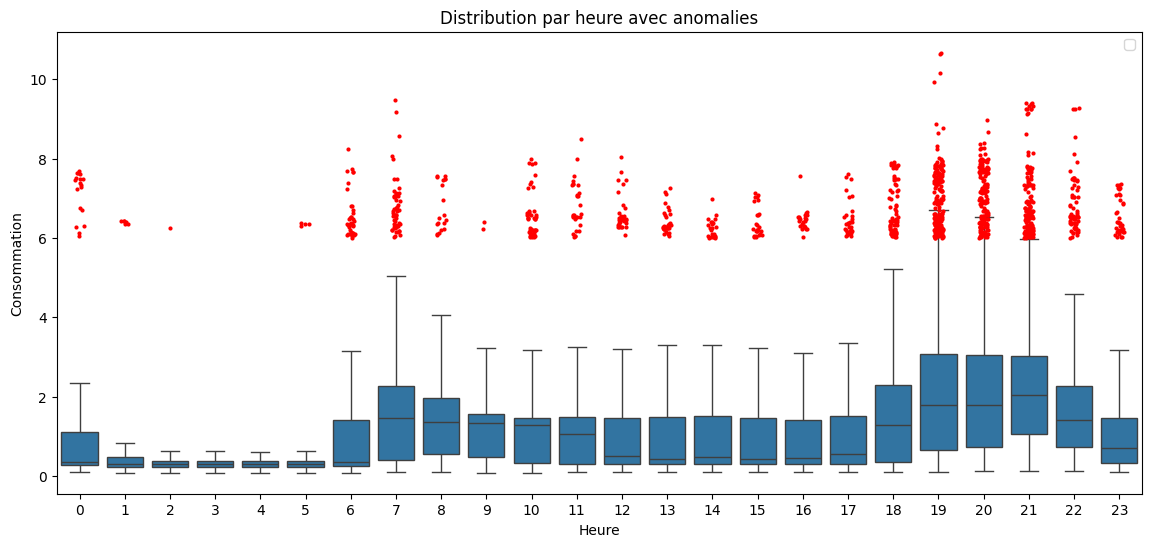

In [ ]:
#boxplot par heure pour analyser la distribution de la consommation électrique et identifier les variations et anomalies selon les moments de la journée, en mettant en évidence les anomalies fortes détectées précédemment.
#Contrairement à une simple moyenne, le boxplot permet de visualiser la variabilité et les outliers, ce qui est essentiel pour analyser des anomalies
plt.figure(figsize=(14,6))

sns.boxplot(
    x="hour",
    y="Global_active_power",
    data=df,
    showfliers=False
)

sns.stripplot(
    x="hour",
    y="Global_active_power",
    data=df[df["anomaly_strong"]],
    color="red",
    size=3,
)

plt.title("Distribution par heure avec anomalies")
plt.xlabel("Heure")
plt.ylabel("Consommation")
plt.legend()

plt.show()

In [ ]:
#### Interprétation

#La consommation électrique varie significativement selon l’heure de la journée, avec des pics observés à certaines périodes.

#Le boxplot met en évidence une forte dispersion durant ces périodes, indiquant une variabilité importante de la consommation.

#Les anomalies détectées sont majoritairement concentrées durant ces heures de forte activité, ce qui suggère qu’elles sont liées à des usages énergétiques spécifiques.

#Cela confirme l’intérêt d’une approche contextuelle basée sur le temps pour améliorer la détection d’anomalies.

In [51]:
#On va regarde maintenant les consommation electrique en fonction des saisons pour identifier les variations saisonnières et les anomalies spécifiques à certaines périodes de l'année.
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

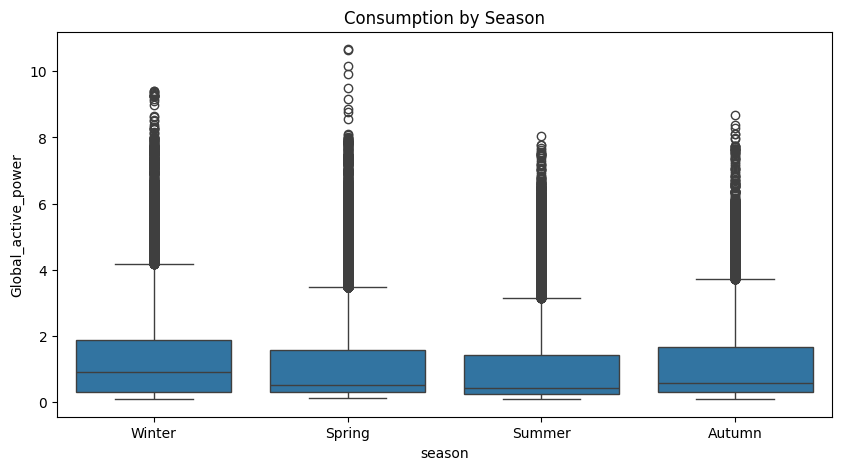

In [57]:


plt.figure(figsize=(10,5))

sns.boxplot(
    x="season",
    y="Global_active_power",
    data=df
)

plt.title("Consumption by Season")
plt.show()

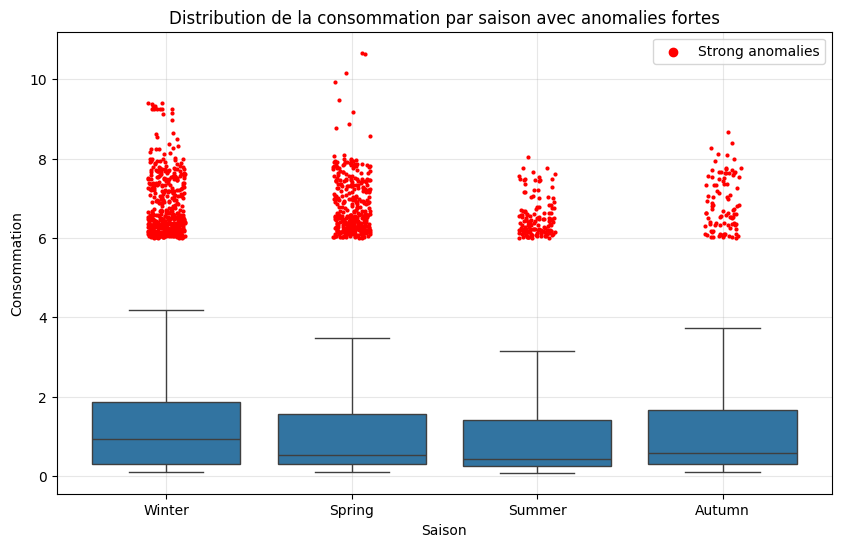

In [58]:
#boxplot par saison en mettant en evidence les anomalies fortes 
plt.figure(figsize=(10,6))

# Boxplot (distribution normale)
sns.boxplot(
    x="season",
    y="Global_active_power",
    data=df,
    showfliers=False
)

# Ajout des anomalies fortes
sns.stripplot(
    x="season",
    y="Global_active_power",
    data=df[df["anomaly_strong"]],
    color="red",
    size=3
)

# Légende propre
plt.scatter([], [], color="red", label="Strong anomalies")
plt.legend()

plt.title("Distribution de la consommation par saison avec anomalies fortes")
plt.xlabel("Saison")
plt.ylabel("Consommation")

plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
### Analyse par saison avec anomalies

#La consommation électrique varie selon les saisons, avec des niveaux généralement plus élevés en hiver et en été, probablement en raison des besoins en chauffage.

#Les anomalies fortes sont principalement concentrées dans les saisons où la consommation est élevée, ce qui suggère qu’elles sont liées à des usages énergétiques intensifs.

#Cela confirme que les anomalies ne sont pas aléatoires mais dépendent du contexte saisonnier.

#On peut donc en conclure que lorsque les temperatures sont extrêmes (hiver ou été), les usages énergétiques sont plus intenses, ce qui génère des anomalies de consommation plus fréquentes et plus fortes à cause de l'utilisation du chauffage ou de la clim 

In [59]:
#Cette approche permet de mieux identifier les anomalies significatives tout en filtrant les fluctuations normales de la consommation d'énergie.
#Maintenant on va essayer d'identifier les anomalies en fonction du jour, de l'heure et de la saison pour mieux comprendre les contextes dans lesquels les anomalies se produisent.
#On va calculer les stats par groupe (jour, heure, saison) pour mieux comprendre les contextes d'anomalies et identifier les moments où elles sont les plus fréquentes et les plus fortes.
group_stats = df.groupby(
    ["hour", "day_name", "season"]
)["Global_active_power"].agg(["mean", "std"]).reset_index()

In [60]:
#Je le fusionne avec mon dataset pour chaque ligne de mon dataset, j'aurai la moyenne et l'écart type de la consommation d'énergie pour le groupe correspondant à l'heure, au jour et à la saison de cette ligne.
df = df.merge(group_stats, on=["hour", "day_name", "season"], how="left")

In [61]:
#Detection des anomalies en fonction du contexte temporel (jour, heure, saison) pour mieux identifier les points de données qui s'écartent significativement de la moyenne dans leur groupe respectif.
#On va d'abord mêttre un z-score pour mesurer l'écart de chaque point de données par rapport à la moyenne de son groupe, en tenant compte de l'écart type pour normaliser cet écart.
df["z_score_context"] = (
    df["Global_active_power"] - df["mean"]
) / df["std"]


In [73]:
#Les anomalies contextuelles sont ensuite définies comme les points de données dont le z-score est supérieur à un certain seuil (par exemple 2 ou 3), ce qui permet d'identifier les points qui s'écartent significativement de la moyenne de leur groupe respectif.
#On va mêttre notre z-score à un seuil de 3 pour ne garder que les anomalies les plus significatives, ce qui permet d'identifier les points de données qui s'écartent fortement de la moyenne de leur groupe.
df["anomaly_context"] = abs(df["z_score_context"]) > 4
df["z_score_context"] = df["z_score_context"].replace([float("inf"), -float("inf")], 0)
df["z_score_context"] = df["z_score_context"].fillna(0)
#On remplace les valeurs infinies par 0 pour éviter les problèmes de calcul et on remplace les valeurs NaN par 0 pour les points où l'écart type est nul, ce qui permet de gérer les cas où il n'y a pas de variabilité dans le groupe.
df["anomaly_context"].value_counts()
#On verifie que le seuil ne soit pas trop strict pour ne pas filtrer des anomalies significatives, mais aussi pas trop laxiste pour ne pas inclure des points normaux.
#On a un bon seuil de 3 puisqu'on a bien réduit le nombre d'anomalies tout en conservant les points les plus significatifs.

anomaly_context
False    259790
True        850
Name: count, dtype: int64

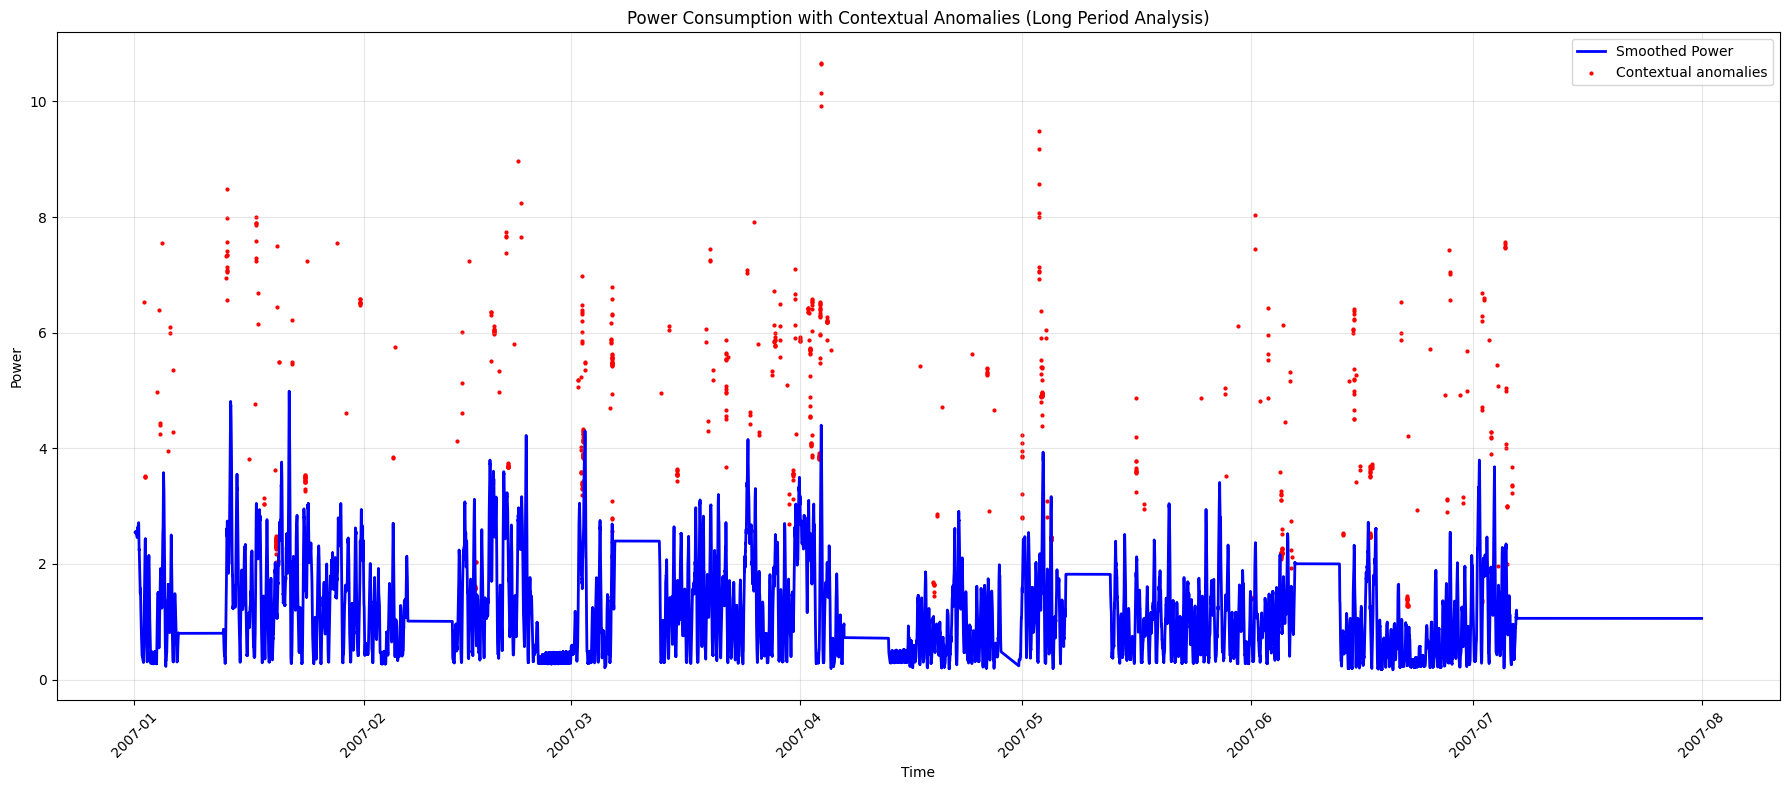

In [75]:
# Tri des données par ordre chronologique
# Permet de garantir la cohérence des calculs sur séries temporelles (notamment la moyenne mobile)
df = df.sort_values("DateTime")


# Interpolation des valeurs manquantes
# Remplit les trous dans les données en estimant les valeurs intermédiaires
# Le paramètre limit=50 évite de lisser des zones trop longues (plus réaliste)
df["Global_active_power"] = df["Global_active_power"].interpolate(limit=50) 


# Calcul d'une moyenne mobile (rolling mean)
# Permet de lisser les fluctuations à court terme et de faire ressortir la tendance globale
# window=300 : taille de la fenêtre (nombre de points)
# min_periods=150 : nombre minimum de points requis pour calculer la moyenne
df["rolling_mean"] = (
    df["Global_active_power"]
    .rolling(window=300, min_periods=150)
    .mean()
)


# Filtrage des données sur une période spécifique (ici plusieurs mois)
# Permet de visualiser une tendance sur une période plus longue
df_sample = df[
    (df["DateTime"] >= "2007-01-01") &
    (df["DateTime"] <= "2007-08-01")
]


# Création du graphique
plt.figure(figsize=(18,8))


# Affichage de la consommation lissée
# La courbe permet de visualiser la tendance générale de consommation
plt.plot(
    df_sample["DateTime"],
    df_sample["rolling_mean"],
    label="Smoothed Power",
    linewidth=2,
    color="blue"
)


# Affichage des anomalies contextuelles
# Les points rouges représentent les valeurs détectées comme anormales
# selon le z-score contextuel (heure, jour, saison)
plt.scatter(
    df_sample.loc[df_sample["anomaly_context"], "DateTime"],
    df_sample.loc[df_sample["anomaly_context"], "Global_active_power"],
    color="red",
    s=4,
    label="Contextual anomalies"
)


# Ajout des éléments de lisibilité
plt.legend()
plt.title("Power Consumption with Contextual Anomalies (Long Period Analysis)")
plt.xlabel("Time")
plt.ylabel("Power")

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [76]:
#nettoyage du dataset
df = df.drop(columns=[
    "Date",
    "Time",
    "mean",
    "std",
])

In [77]:
## Insights et interprétation

### Analyse des variations journalières
#La consommation électrique présente des variations significatives selon l’heure de la journée.
#Les périodes en soirée (notamment entre 18h et 22h) concentrent à la fois les niveaux de consommation les plus élevés et une plus grande dispersion des valeurs.
#Cela s’explique par une intensification des usages domestiques (éclairage, appareils électroménagers, chauffage).
#Les anomalies détectées sont majoritairement concentrées durant ces périodes, ce qui suggère qu’elles correspondent à des pics d’activité plutôt qu’à des comportements aléatoires.

### Analyse saisonnière de la consommation
#La consommation énergétique varie selon les saisons, avec des niveaux globalement plus élevés en hiver et plus modérés au printemps et en été.
#Cette variation est cohérente avec les besoins en chauffage, qui constituent un facteur majeur de consommation.
#Les anomalies sont plus fréquentes durant les périodes de forte consommation, ce qui suggère que les pics énergétiques amplifient les écarts par rapport au comportement normal.

### Anomalie atypique en période printanière
#Une anomalie particulièrement marquée est observée au mois d’avril, ce qui est inattendu compte tenu de la saison.
#Le printemps étant généralement associé à une consommation modérée, ce pic ne correspond pas au comportement énergétique habituel.
#Cela suggère un événement ponctuel ou un usage exceptionnel (équipement énergivore, activité inhabituelle, ou anomalie technique).
#Cette observation met en évidence l’intérêt d’une analyse contextuelle permettant d’identifier des anomalies indépendamment des tendances saisonnières.

### Limites et amélioration de la détection
#Une approche basée sur un seuil global peut conduire à la détection de faux positifs, notamment durant les périodes de forte consommation.
#L’introduction d’un z-score contextuel (heure, jour, saison) permet d’améliorer la pertinence des anomalies détectées en tenant compte du comportement attendu.
#Cette approche réduit les biais liés à la saisonnalité et aux cycles journaliers.